In [ ]:
import sys
from pathlib import Path

import numpy as np
import torch
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, desc=None):
        if desc:
            print(desc)
        return iterable


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / "module").exists() and (p / "configs").exists():
            return p
    fallback = Path("/N/u/kmluong/BigRed200/regDL-TCIP")
    if fallback.exists():
        return fallback
    raise FileNotFoundError("Cannot find repo root containing module/ and configs/.")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from visualization.model_loader import load_model_from_paths
from module.training.datasets import load_split_arrays
from module.training.masks import extract_bc_rim_from_y, make_rim_mask_like, make_smooth_phi


In [ ]:
# =========================
# User config
# =========================
DS = "CMIP6"
SPLIT = "test"

DATA_SOURCE = Path(f"/N/slate/kmluong/regDL-TCIP/{DS}/tmp")
Z_PATH = DATA_SOURCE / f"{SPLIT}_Z.npy"
OUTPUT_DIR = Path(f"/N/slate/kmluong/regDL-TCIP/{DS}/rollout_outputs")

MODEL_CONFIG_PATH_BC = Path(f"/N/slate/kmluong/regDL-TCIP/{DS}/checkpoints/AFNO-TCP-BC.json")
MODEL_CHECKPOINT_PATH_BC = Path(f"/N/slate/kmluong/regDL-TCIP/{DS}/checkpoints/trained-AFNO-TCP-BC.pt")

MODEL_CONFIG_PATH_NBC = Path(f"/N/slate/kmluong/regDL-TCIP/{DS}/checkpoints/AFNO-TCP-NO-BC.json")
MODEL_CHECKPOINT_PATH_NBC = Path(f"/N/slate/kmluong/regDL-TCIP/{DS}/checkpoints/trained-AFNO-TCP-NO-BC.pt")

ROLLOUT_STEPS = 2
RIM = 1
BATCH_SIZE = 16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("DEVICE:", DEVICE)
print("OUTPUT_DIR:", OUTPUT_DIR)


In [ ]:
def load_data_array(data_source: str | Path, split: str = "test"):
    p = Path(data_source)
    if p.is_dir():
        train, val, test = load_split_arrays(p)
        split = split.lower()
        if split == "train":
            arr = train
        elif split == "val":
            if val is None:
                raise ValueError("No val.npy found in this temp dir.")
            arr = val
        elif split == "test":
            arr = test
        else:
            raise ValueError(f"Invalid split: {split}")
        source_kind = f"temp_dir:{split}"
    else:
        if p.suffix != ".npy":
            raise ValueError(f"DATA_SOURCE must be temp dir or .npy file, got: {p}")
        arr = np.load(p, mmap_mode="r")
        source_kind = "npy"

    if arr.ndim != 5:
        raise ValueError(f"Data must have shape [N,F,H,W,C], got: {arr.shape}")
    return arr, source_kind


def frames_to_model_tensor(frames_np: np.ndarray, device: str):
    """[B,T,H,W,C] -> [B,T,C,H,W]."""
    return torch.from_numpy(np.transpose(frames_np, (0, 1, 4, 2, 3)).copy()).float().to(device)


def targets_to_model_tensor(target_np: np.ndarray, device: str):
    """[B,H,W,C] -> [B,C,H,W]."""
    return torch.from_numpy(np.transpose(target_np, (0, 3, 1, 2)).copy()).float().to(device)


def model_tensor_to_frames(y: torch.Tensor):
    """[B,C,H,W] -> [B,H,W,C] float32 numpy."""
    return np.transpose(y.detach().cpu().numpy(), (0, 2, 3, 1)).astype(np.float32, copy=False)


def run_one_step(model, x, y_for_bc, use_bc: bool, rim: int = 1):
    """
    x: [B,T,C,H,W]
    y_for_bc: [B,C,H,W], the true target frame used only for BC rim construction.
    """
    with torch.no_grad():
        x_in = x
        y_in = y_for_bc

        if getattr(model, "x_scaler", None) is not None:
            x_in = model.x_scaler.norm(x_in)
        if getattr(model, "y_scaler", None) is not None:
            y_in = model.y_scaler.norm(y_in)

        if use_bc:
            b_fill = extract_bc_rim_from_y(y_in, rim=rim)
            bc_mask = make_rim_mask_like(y_in, rim=rim)
            bc_in = torch.cat([b_fill, bc_mask], dim=1)
            y_free = model(x_in, bc_in)

            phi = make_smooth_phi(
                H=y_in.shape[-2],
                W=y_in.shape[-1],
                rim=rim,
                device=y_in.device,
                dtype=y_in.dtype,
            )
            y_pred_norm = phi * y_free + (1.0 - phi) * b_fill
        else:
            y_pred_norm = model(x_in)

        if getattr(model, "y_scaler", None) is not None:
            y_pred = model.y_scaler.denorm(y_pred_norm)
        else:
            y_pred = y_pred_norm

    return y_pred


In [ ]:
def load_rollout_model(config_path: Path, checkpoint_path: Path):
    model, meta = load_model_from_paths(
        config_path=config_path,
        checkpoint_path=checkpoint_path,
        map_location=DEVICE,
        strict=True,
        eval_mode=True,
    )
    model = model.to(DEVICE)
    model.eval()
    return model, meta


arr, source_kind = load_data_array(DATA_SOURCE, split=SPLIT)
Z = np.load(Z_PATH, mmap_mode="r") if Z_PATH.exists() else None

model_bc, meta_bc = load_rollout_model(MODEL_CONFIG_PATH_BC, MODEL_CHECKPOINT_PATH_BC)
model_nbc, meta_nbc = load_rollout_model(MODEL_CONFIG_PATH_NBC, MODEL_CHECKPOINT_PATH_NBC)

step_in_bc = int(meta_bc["config"]["num_times"])
step_in_nbc = int(meta_nbc["config"]["num_times"])
if step_in_bc != step_in_nbc:
    raise ValueError(f"BC/noBC step_in mismatch: {step_in_bc} vs {step_in_nbc}")
step_in = step_in_bc

N, F, H, W, C = arr.shape
num_start_f = F - step_in - ROLLOUT_STEPS + 1
if num_start_f <= 0:
    raise ValueError(
        f"Not enough frames for rollout: F={F}, step_in={step_in}, ROLLOUT_STEPS={ROLLOUT_STEPS}"
    )
if Z is not None and Z.shape[:2] != arr.shape[:2]:
    raise ValueError(f"Z shape {Z.shape} is not aligned with arr shape {arr.shape}")

print("source_kind:", source_kind)
print("arr shape [N,F,H,W,C]:", arr.shape)
print("Z shape:", None if Z is None else Z.shape)
print("step_in:", step_in)
print("rollout starts per sample:", num_start_f)
print("target frame indices per start_f:")
for start_f in range(num_start_f):
    print(f"  start_f={start_f}: rollout targets", [start_f + step_in + r for r in range(ROLLOUT_STEPS)])


In [ ]:
def make_index_metadata(num_samples: int, num_start_f: int, step_in: int, rollout_steps: int):
    sample_index = np.arange(num_samples, dtype=np.int32)
    start_frame = np.arange(num_start_f, dtype=np.int32)
    target_frame = np.empty((num_start_f, rollout_steps), dtype=np.int32)
    for start_f in range(num_start_f):
        target_frame[start_f, :] = [start_f + step_in + r for r in range(rollout_steps)]
    return sample_index, start_frame, target_frame


def run_rollout_to_memmap(model, arr, output_path: Path, use_bc: bool, step_in: int, rollout_steps: int, batch_size: int, rim: int):
    N, F, H, W, C = arr.shape
    num_start_f = F - step_in - rollout_steps + 1
    out = np.lib.format.open_memmap(
        output_path,
        mode="w+",
        dtype=np.float32,
        shape=(N, num_start_f, rollout_steps, H, W, C),
    )

    for start_f in range(num_start_f):
        for b0 in tqdm(range(0, N, batch_size), desc=f"{output_path.name} start_f={start_f}"):
            b1 = min(b0 + batch_size, N)
            x = frames_to_model_tensor(arr[b0:b1, start_f : start_f + step_in, ...], DEVICE)

            for r in range(rollout_steps):
                target_f = start_f + step_in + r
                y_for_bc = targets_to_model_tensor(arr[b0:b1, target_f, ...], DEVICE)
                y_pred = run_one_step(model, x, y_for_bc=y_for_bc, use_bc=use_bc, rim=rim)

                out[b0:b1, start_f, r, ...] = model_tensor_to_frames(y_pred)
                x = torch.cat([x[:, 1:, ...], y_pred.unsqueeze(1)], dim=1)

            del x, y_for_bc, y_pred
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    out.flush()
    return output_path


sample_index, start_frame, target_frame = make_index_metadata(N, num_start_f, step_in, ROLLOUT_STEPS)
index_path = OUTPUT_DIR / f"{DS.lower()}_{SPLIT}_rollout{ROLLOUT_STEPS}_index.npz"
np.savez(
    index_path,
    sample_index=sample_index,
    start_frame=start_frame,
    target_frame=target_frame,
    step_in=np.array(step_in, dtype=np.int32),
    rollout_steps=np.array(ROLLOUT_STEPS, dtype=np.int32),
    arr_shape=np.array(arr.shape, dtype=np.int64),
    z_path=np.array(str(Z_PATH)),
)
print("Saved index metadata:", index_path)

bc_output_path = OUTPUT_DIR / f"{DS.lower()}_{SPLIT}_rollout{ROLLOUT_STEPS}_BC.npy"
nbc_output_path = OUTPUT_DIR / f"{DS.lower()}_{SPLIT}_rollout{ROLLOUT_STEPS}_NOBC.npy"

run_rollout_to_memmap(
    model_bc,
    arr,
    bc_output_path,
    use_bc=True,
    step_in=step_in,
    rollout_steps=ROLLOUT_STEPS,
    batch_size=BATCH_SIZE,
    rim=RIM,
)
run_rollout_to_memmap(
    model_nbc,
    arr,
    nbc_output_path,
    use_bc=False,
    step_in=step_in,
    rollout_steps=ROLLOUT_STEPS,
    batch_size=BATCH_SIZE,
    rim=RIM,
)

print("Saved BC rollout:", bc_output_path)
print("Saved NOBC rollout:", nbc_output_path)


In [ ]:
# Quick alignment/readback check.
bc = np.load(bc_output_path, mmap_mode="r")
nbc = np.load(nbc_output_path, mmap_mode="r")
idx = np.load(index_path)

print("BC output shape   [N,start_f,rollout_step,H,W,C]:", bc.shape)
print("NOBC output shape [N,start_f,rollout_step,H,W,C]:", nbc.shape)
print("target_frame index matrix [start_f, rollout_step]:")
print(idx["target_frame"])

if Z is not None:
    n = int(idx["sample_index"][0])
    start_f = int(idx["start_frame"][0])
    for r, target_f in enumerate(idx["target_frame"][start_f]):
        print(f"rollout_step={r + 1}: output[{n}, {start_f}, {r}] aligns with Z[{n}, {int(target_f)}] =", Z[n, int(target_f)])


In [ ]:
# =========================
# Vortex detection on rollout outputs and reference frames
# =========================
# Channel convention:
#   0 U10m, 1 V10m, 2 SST, 3 LANDMASK,
#   4 U28, 5 V28, 6 U05, 7 V05,
#   8 T23, 9 QVAPOR10, 10 PHB10, 11 PSFC,
#   12 TRUE_LAT, 13 TRUE_LONG

import csv
from pathlib import Path
import numpy as np

# ---- Configurable detection settings ----
PSFC_CHANNEL = 11
U10_CHANNEL = 0
V10_CHANNEL = 1
SST_CHANNEL = 2
WARM_CORE_CHANNEL = 8  # T23
LAT_CHANNEL = -2       # TRUE_LAT, configurable from the end of the channel axis
LON_CHANNEL = -1       # TRUE_LONG, configurable from the end of the channel axis
EARTH_RADIUS_KM = 6371.0088

CENTER_SEARCH_RADIUS_PIXELS = 30  # pmin search radius around storm-centered crop center
VMAX_SEARCH_RADIUS_PIXELS = 30    # vmax10 search radius around pmin
ANOMALY_SEARCH_RADIUS_PIXELS = 30 # max anomaly search radius around pmin
ANOMALY_BACKGROUND_INNER_RADIUS_PIXELS = 30
ANOMALY_BACKGROUND_OUTER_RADIUS_PIXELS = 45

VORTEX_CSV_PATH = OUTPUT_DIR / f"{DS.lower()}_{SPLIT}_rollout{ROLLOUT_STEPS}_vortex_metrics.csv"


def _disk_mask(h: int, w: int, center_y: float, center_x: float, radius: float):
    yy, xx = np.ogrid[:h, :w]
    return (yy - center_y) ** 2 + (xx - center_x) ** 2 <= radius ** 2


def _annulus_mask(h: int, w: int, center_y: float, center_x: float, inner_radius: float, outer_radius: float):
    yy, xx = np.ogrid[:h, :w]
    dist2 = (yy - center_y) ** 2 + (xx - center_x) ** 2
    return (dist2 >= inner_radius ** 2) & (dist2 <= outer_radius ** 2)


def _masked_argmin(field: np.ndarray, mask: np.ndarray):
    vals = np.where(mask, field, np.nan)
    flat_idx = int(np.nanargmin(vals))
    y, x = np.unravel_index(flat_idx, field.shape)
    return y, x, float(field[y, x])


def _masked_argmax(field: np.ndarray, mask: np.ndarray):
    vals = np.where(mask, field, np.nan)
    flat_idx = int(np.nanargmax(vals))
    y, x = np.unravel_index(flat_idx, field.shape)
    return y, x, float(field[y, x])


def _latlon_at(frame_hwc: np.ndarray, y: int, x: int):
    """Read a valid (lat, lon) pair from configurable coordinate channels."""
    c = frame_hwc.shape[-1]
    lat_ch = LAT_CHANNEL % c
    lon_ch = LON_CHANNEL % c
    lat = float(frame_hwc[y, x, lat_ch])
    lon = float(frame_hwc[y, x, lon_ch])
    if not np.isfinite(lat) or not np.isfinite(lon) or not (-90.0 <= lat <= 90.0):
        return np.nan, np.nan
    return lat, lon


def _east_north_displacement_km(lat0: float, lon0: float, lat1: float, lon1: float):
    """Local east/north displacement from point 0 to point 1, plus magnitude."""
    if not np.all(np.isfinite([lat0, lon0, lat1, lon1])):
        return np.nan, np.nan, np.nan

    dlat_rad = np.deg2rad(lat1 - lat0)
    dlon_deg = (lon1 - lon0 + 180.0) % 360.0 - 180.0
    dlon_rad = np.deg2rad(dlon_deg)
    mean_lat_rad = np.deg2rad(0.5 * (lat0 + lat1))

    north_km = EARTH_RADIUS_KM * dlat_rad
    east_km = EARTH_RADIUS_KM * np.cos(mean_lat_rad) * dlon_rad
    distance_km = float(np.hypot(east_km, north_km))
    return float(east_km), float(north_km), distance_km


def _rmw_km(coord_frame_hwc: np.ndarray, vortex_metrics: dict):
    """RMW between detected pmin and vmax pixels using coordinates from coord_frame_hwc."""
    p_lat, p_lon = _latlon_at(
        coord_frame_hwc,
        int(vortex_metrics["pmin_y"]),
        int(vortex_metrics["pmin_x"]),
    )
    v_lat, v_lon = _latlon_at(
        coord_frame_hwc,
        int(vortex_metrics["vmax10_y"]),
        int(vortex_metrics["vmax10_x"]),
    )
    return _east_north_displacement_km(p_lat, p_lon, v_lat, v_lon)[2]


def _center_movement_metrics(
    previous_coord_frame_hwc: np.ndarray,
    previous_vortex_metrics: dict,
    current_coord_frame_hwc: np.ndarray,
    current_vortex_metrics: dict,
    prefix: str,
):
    """Movement of the pressure-minimum center from the previous frame to this frame."""
    prev_lat, prev_lon = _latlon_at(
        previous_coord_frame_hwc,
        int(previous_vortex_metrics["pmin_y"]),
        int(previous_vortex_metrics["pmin_x"]),
    )
    curr_lat, curr_lon = _latlon_at(
        current_coord_frame_hwc,
        int(current_vortex_metrics["pmin_y"]),
        int(current_vortex_metrics["pmin_x"]),
    )
    if np.all(np.isfinite([prev_lat, prev_lon, curr_lat, curr_lon])):
        dlat_deg = float(curr_lat - prev_lat)
        dlon_deg = float((curr_lon - prev_lon + 180.0) % 360.0 - 180.0)
    else:
        dlat_deg = np.nan
        dlon_deg = np.nan

    east_km, north_km, distance_km = _east_north_displacement_km(
        prev_lat,
        prev_lon,
        curr_lat,
        curr_lon,
    )
    return {
        f"{prefix}_dlat_deg": dlat_deg,
        f"{prefix}_dlon_deg": dlon_deg,
        f"{prefix}_east_km": east_km,
        f"{prefix}_north_km": north_km,
        f"{prefix}_distance_km": distance_km,
    }


def _local_anomaly_metric(field: np.ndarray, pmin_y: int, pmin_x: int, prefix: str):
    h, w = field.shape
    search_mask = _disk_mask(h, w, pmin_y, pmin_x, ANOMALY_SEARCH_RADIUS_PIXELS)
    bg_mask = _annulus_mask(
        h,
        w,
        pmin_y,
        pmin_x,
        ANOMALY_BACKGROUND_INNER_RADIUS_PIXELS,
        ANOMALY_BACKGROUND_OUTER_RADIUS_PIXELS,
    )

    background = float(np.nanmean(field[bg_mask])) if np.any(bg_mask) else float(np.nanmean(field))
    anomaly = field - background
    max_y, max_x, max_anom = _masked_argmax(anomaly, search_mask)
    pmin_point_anom = float(anomaly[pmin_y, pmin_x])

    return {
        f"{prefix}_background_mean": background,
        f"{prefix}_value_at_pmin": float(field[pmin_y, pmin_x]),
        f"{prefix}_anomaly_at_pmin": pmin_point_anom,
        f"{prefix}_anomaly_max": max_anom,
        f"{prefix}_anomaly_max_y": int(max_y),
        f"{prefix}_anomaly_max_x": int(max_x),
        f"{prefix}_value_at_anomaly_max": float(field[max_y, max_x]),
    }


def detect_vortex_metrics(frame_hwc: np.ndarray, center_yx=None):
    """Detect pmin, local vmax10, SST anomaly, and warm-core anomaly from one [H,W,C] frame."""
    if frame_hwc.ndim != 3:
        raise ValueError(f"Expected [H,W,C], got {frame_hwc.shape}")

    h, w, c = frame_hwc.shape
    required = max(PSFC_CHANNEL, U10_CHANNEL, V10_CHANNEL, SST_CHANNEL, WARM_CORE_CHANNEL)
    if c <= required:
        raise ValueError(f"Frame has {c} channels; need channel index {required}")

    if center_yx is None:
        center_y, center_x = (h - 1) / 2.0, (w - 1) / 2.0
    else:
        center_y, center_x = center_yx

    psfc = frame_hwc[:, :, PSFC_CHANNEL]
    u10 = frame_hwc[:, :, U10_CHANNEL]
    v10 = frame_hwc[:, :, V10_CHANNEL]
    wind10 = np.sqrt(u10 ** 2 + v10 ** 2)

    center_mask = _disk_mask(h, w, center_y, center_x, CENTER_SEARCH_RADIUS_PIXELS)
    pmin_y, pmin_x, pmin_value = _masked_argmin(psfc, center_mask)

    vmax_mask = _disk_mask(h, w, pmin_y, pmin_x, VMAX_SEARCH_RADIUS_PIXELS)
    vmax_y, vmax_x, vmax_value = _masked_argmax(wind10, vmax_mask)

    result = {
        "pmin": pmin_value,
        "pmin_y": int(pmin_y),
        "pmin_x": int(pmin_x),
        "pmin_dist_from_center_px": float(np.hypot(pmin_y - center_y, pmin_x - center_x)),
        "vmax10": vmax_value,
        "vmax10_y": int(vmax_y),
        "vmax10_x": int(vmax_x),
        "vmax10_dist_from_pmin_px": float(np.hypot(vmax_y - pmin_y, vmax_x - pmin_x)),
        "u10_at_vmax": float(u10[vmax_y, vmax_x]),
        "v10_at_vmax": float(v10[vmax_y, vmax_x]),
    }
    result.update(_local_anomaly_metric(frame_hwc[:, :, SST_CHANNEL], pmin_y, pmin_x, "sst"))
    result.update(_local_anomaly_metric(frame_hwc[:, :, WARM_CORE_CHANNEL], pmin_y, pmin_x, "warm_core"))
    return result


# ---- Load rollout outputs and reference data ----
bc_rollout = np.load(OUTPUT_DIR / f"{DS.lower()}_{SPLIT}_rollout{ROLLOUT_STEPS}_BC.npy", mmap_mode="r")
nbc_rollout = np.load(OUTPUT_DIR / f"{DS.lower()}_{SPLIT}_rollout{ROLLOUT_STEPS}_NOBC.npy", mmap_mode="r")
idx = np.load(OUTPUT_DIR / f"{DS.lower()}_{SPLIT}_rollout{ROLLOUT_STEPS}_index.npz")
ref_arr, _ = load_data_array(DATA_SOURCE, split=SPLIT)
Z_ref = np.load(Z_PATH, mmap_mode="r") if Path(Z_PATH).exists() else None

sample_index = idx["sample_index"]
start_frame = idx["start_frame"]
target_frame = idx["target_frame"]

rows = []
for n_pos, n in enumerate(tqdm(sample_index, desc="vortex detection samples")):
    n = int(n)
    for sf_pos, sf in enumerate(start_frame):
        sf = int(sf)
        first_target_f = int(target_frame[sf_pos, 0])
        previous_truth_frame = ref_arr[n, first_target_f - 1, ...]
        previous_truth_metrics = detect_vortex_metrics(previous_truth_frame)

        # Step 1 starts from the final true input frame. Later steps use the
        # previous rollout frame and detected center for each prediction source.
        previous_frames = {
            "BC": previous_truth_frame,
            "NOBC": previous_truth_frame,
            "REF": previous_truth_frame,
        }
        previous_metrics = {
            "BC": previous_truth_metrics,
            "NOBC": previous_truth_metrics,
            "REF": previous_truth_metrics,
        }

        for r in range(int(idx["rollout_steps"])):
            target_f = int(target_frame[sf_pos, r])
            frames = {
                "BC": bc_rollout[n_pos, sf_pos, r, ...],
                "NOBC": nbc_rollout[n_pos, sf_pos, r, ...],
                "REF": ref_arr[n, target_f, ...],
            }
            metrics_by_source = {
                source: detect_vortex_metrics(frame)
                for source, frame in frames.items()
            }

            ref_frame = frames["REF"]
            ref_metrics = metrics_by_source["REF"]
            true_rmw_km = _rmw_km(ref_frame, ref_metrics)
            true_movement = _center_movement_metrics(
                previous_frames["REF"],
                previous_metrics["REF"],
                ref_frame,
                ref_metrics,
                "movement_true",
            )

            for source, frame in frames.items():
                metrics = metrics_by_source[source]
                row = {
                    "source": source,
                    "sample_n": n,
                    "start_f": sf,
                    "rollout_step": r + 1,
                    "target_frame": target_f,
                }
                if Z_ref is not None:
                    row.update({
                        "z_lon": float(Z_ref[n, target_f, 0]) if Z_ref.shape[-1] > 0 else np.nan,
                        "z_lat": float(Z_ref[n, target_f, 1]) if Z_ref.shape[-1] > 1 else np.nan,
                    })
                row.update(metrics)
                row.update({
                    "rmw_true_km": true_rmw_km,
                    "rmw_pred_truebase_km": _rmw_km(ref_frame, metrics),
                    "rmw_pred_predbase_km": _rmw_km(frame, metrics),
                })
                row.update(true_movement)
                row.update(_center_movement_metrics(
                    ref_arr[n, target_f - 1, ...],
                    previous_metrics[source],
                    ref_frame,
                    metrics,
                    "movement_pred_truebase",
                ))
                row.update(_center_movement_metrics(
                    previous_frames[source],
                    previous_metrics[source],
                    frame,
                    metrics,
                    "movement_pred_predbase",
                ))
                rows.append(row)

            previous_frames = frames
            previous_metrics = metrics_by_source

fieldnames = list(rows[0].keys()) if rows else []
with VORTEX_CSV_PATH.open("w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(rows)

print(f"Saved vortex metrics CSV: {VORTEX_CSV_PATH}")
print(f"rows: {len(rows)}")
print("sources:", sorted({row["source"] for row in rows}))
print("first row:")
print(rows[0] if rows else None)


Saved performance plot: /N/slate/kmluong/regDL-TCIP/CMIP6/rollout_outputs/cmip6_test_rollout2_vortex_metrics_strongest_50pct_mae_rmse.png


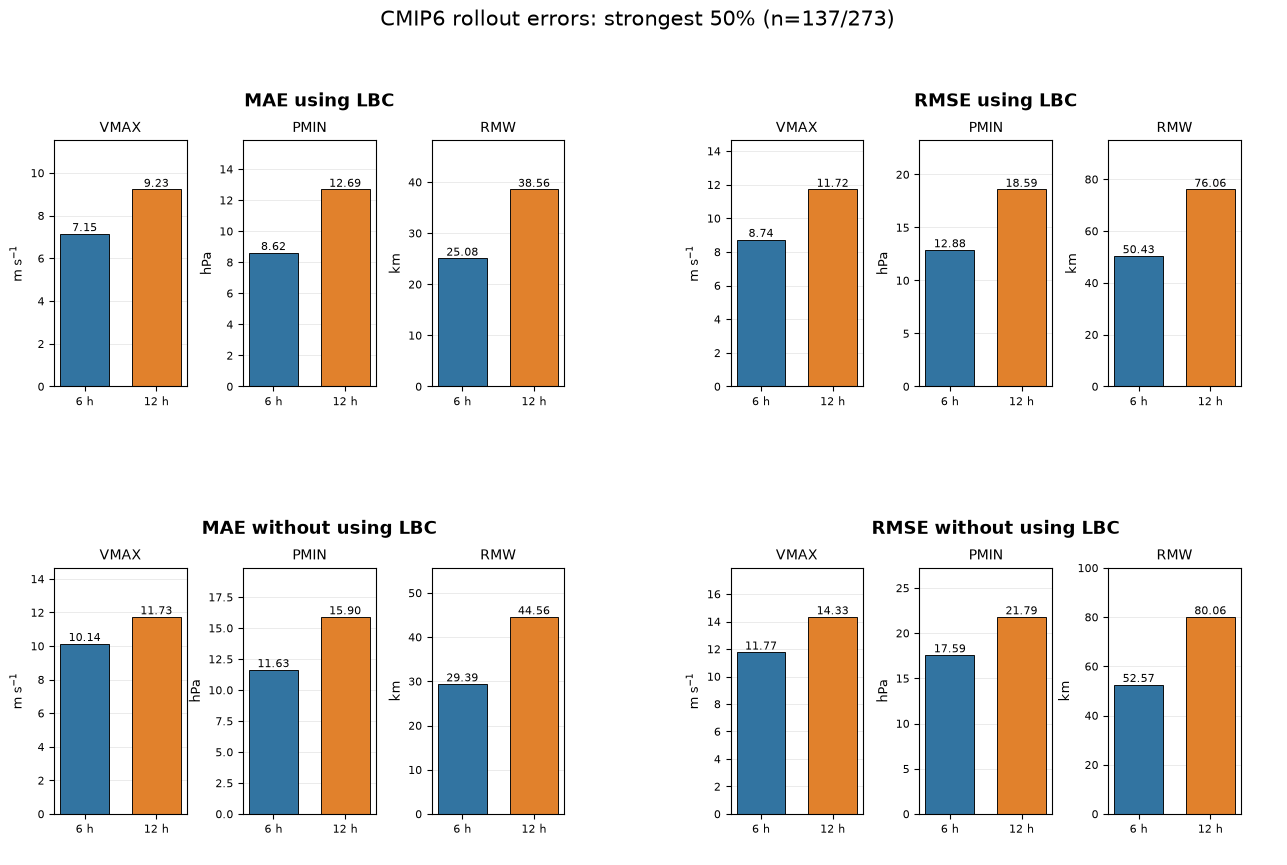

Selected 137 storms (strongest 50%); REF max-Vmax range = 37.788 to 58.553 m/s
source error  lead_h  Vmax_m_s  Pmin_hPa  RMW_km
    BC   MAE       6     7.153     8.617  25.078
    BC   MAE      12     9.228    12.690  38.561
    BC  RMSE       6     8.738    12.882  50.425
    BC  RMSE      12    11.717    18.586  76.061
  NOBC   MAE       6    10.142    11.631  29.392
  NOBC   MAE      12    11.734    15.899  44.556
  NOBC  RMSE       6    11.767    17.587  52.575
  NOBC  RMSE      12    14.333    21.789  80.057


In [6]:
# Standalone four-panel rollout performance plot
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# =========================
# User config
# =========================
METRICS_CSV_PATH = Path(
    "/N/slate/kmluong/regDL-TCIP/CMIP6/rollout_outputs/"
    "cmip6_test_rollout2_vortex_metrics.csv"
)
PERCENT = 50  # +50: strongest 50%; -50: weakest 50%; +100: all storms.
RMW_PRED_COLUMN = "rmw_pred_truebase_km"

selection_tag = (
    f"strongest_{abs(PERCENT):g}pct" if PERCENT > 0
    else f"weakest_{abs(PERCENT):g}pct"
)
PERFORMANCE_PLOT_PATH = METRICS_CSV_PATH.with_name(
    f"{METRICS_CSV_PATH.stem}_{selection_tag}_mae_rmse.png"
)


def select_storms_by_ref_vmax(metrics: pd.DataFrame, percent: float):
    """Select storms using each sample's maximum REF Vmax across both rollout steps."""
    if percent == 0 or abs(percent) > 100:
        raise ValueError("PERCENT must be in [-100, 100] and cannot be 0")

    ref = metrics.loc[metrics["source"].eq("REF")]
    storm_intensity = ref.groupby("sample_n", sort=False)["vmax10"].max()
    if storm_intensity.empty:
        raise ValueError("No REF rows found in metrics CSV")

    count = max(1, math.ceil(len(storm_intensity) * abs(percent) / 100.0))
    if percent > 0:
        selected = storm_intensity.nlargest(count)
        selection_name = f"strongest {abs(percent):g}%"
    else:
        selected = storm_intensity.nsmallest(count)
        selection_name = f"weakest {abs(percent):g}%"
    return set(selected.index), selected, selection_name


def pair_prediction_with_ref(
    metrics: pd.DataFrame,
    selected_samples: set,
    source: str,
    rmw_pred_column: str,
):
    keys = ["sample_n", "start_f", "rollout_step", "target_frame"]
    source = source.upper()
    selected = metrics.loc[metrics["sample_n"].isin(selected_samples)]

    ref = (
        selected.loc[selected["source"].eq("REF"), keys + ["vmax10", "pmin", "rmw_true_km"]]
        .drop_duplicates(keys)
        .rename(columns={"vmax10": "vmax10_ref", "pmin": "pmin_ref"})
    )
    pred = selected.loc[
        selected["source"].eq(source),
        keys + ["vmax10", "pmin", rmw_pred_column],
    ]
    if pred.empty:
        raise ValueError(f"No rows found for source={source!r}")

    paired = pred.merge(ref, on=keys, how="inner", validate="one_to_one")
    if len(paired) != len(pred):
        raise ValueError(f"Only paired {len(paired)} of {len(pred)} {source} rows with REF")

    # Signed errors in the displayed physical units.
    paired["Vmax"] = paired["vmax10"] - paired["vmax10_ref"]
    paired["Pmin"] = (paired["pmin"] - paired["pmin_ref"]) / 100.0  # Pa -> hPa
    paired["RMW"] = paired[rmw_pred_column] - paired["rmw_true_km"]
    return paired


def summarize_errors(paired: pd.DataFrame, error_kind: str):
    error_kind = error_kind.upper()
    errors = paired[["rollout_step", "Vmax", "Pmin", "RMW"]].copy()
    if error_kind == "MAE":
        summary = errors.assign(
            Vmax=errors["Vmax"].abs(),
            Pmin=errors["Pmin"].abs(),
            RMW=errors["RMW"].abs(),
        ).groupby("rollout_step")[["Vmax", "Pmin", "RMW"]].mean()
    elif error_kind == "RMSE":
        summary = np.sqrt(
            errors.assign(
                Vmax=errors["Vmax"] ** 2,
                Pmin=errors["Pmin"] ** 2,
                RMW=errors["RMW"] ** 2,
            ).groupby("rollout_step")[["Vmax", "Pmin", "RMW"]].mean()
        )
    else:
        raise ValueError(f"Unsupported error kind: {error_kind}")

    summary = summary.reindex([1, 2])
    if summary.isna().any().any():
        raise ValueError("Both rollout steps 1 and 2 are required")
    return summary


def plot_four_error_panels(
    metrics_csv_path: str | Path,
    percent: float,
    rmw_pred_column: str = "rmw_pred_truebase_km",
    save_path: str | Path | None = None,
):
    metrics = pd.read_csv(metrics_csv_path)
    required = {
        "source", "sample_n", "start_f", "rollout_step", "target_frame",
        "vmax10", "pmin", "rmw_true_km", rmw_pred_column,
    }
    missing = sorted(required.difference(metrics.columns))
    if missing:
        raise KeyError(f"Missing required CSV columns: {missing}")

    selected_ids, selected_intensity, selection_name = select_storms_by_ref_vmax(metrics, percent)
    paired_by_source = {
        source: pair_prediction_with_ref(metrics, selected_ids, source, rmw_pred_column)
        for source in ("BC", "NOBC")
    }
    panel_specs = [
        ("BC", "MAE"),
        ("BC", "RMSE"),
        ("NOBC", "MAE"),
        ("NOBC", "RMSE"),
    ]
    summaries = {
        (source, error_kind): summarize_errors(paired_by_source[source], error_kind)
        for source, error_kind in panel_specs
    }

    metric_specs = [
        ("Vmax", "VMAX", "m s$^{-1}$"),
        ("Pmin", "PMIN", "hPa"),
        ("RMW", "RMW", "km"),
    ]
    lead_labels = ["6 h", "12 h"]
    lead_colors = ["#3274A1", "#E1812C"]
    fig, outer_axes = plt.subplots(2, 2, figsize=(16, 9.5))

    for outer_ax, (source, error_kind) in zip(outer_axes.flat, panel_specs):
        outer_ax.set_axis_off()
        outer_ax.text(
            0.5, 0.98,
            f"{error_kind} {'using LBC' if source == 'BC' else 'without using LBC'}",
            transform=outer_ax.transAxes, ha="center", va="top",
            fontsize=13, fontweight="bold",
        )
        summary = summaries[(source, error_kind)]

        for metric_index, (column, title, unit) in enumerate(metric_specs):
            inset_ax = outer_ax.inset_axes([0.03 + 0.335 * metric_index, 0.12, 0.235, 0.72])
            values = summary[column].to_numpy(dtype=float)
            lead_x = np.arange(len(lead_labels))
            bars = inset_ax.bar(
                lead_x,
                values,
                color=lead_colors,
                width=0.68,
                edgecolor="black",
                linewidth=0.65,
            )
            inset_ax.set_title(title, fontsize=10)
            inset_ax.set_ylabel(unit, fontsize=9)
            inset_ax.set_xticks(lead_x, lead_labels)
            inset_ax.tick_params(labelsize=8)
            inset_ax.set_ylim(0.0, max(float(values.max()) * 1.25, 1e-6))
            inset_ax.grid(axis="y", alpha=0.25, linewidth=0.7)
            inset_ax.set_axisbelow(True)
            for bar, value in zip(bars, values):
                inset_ax.text(
                    bar.get_x() + bar.get_width() / 2.0,
                    bar.get_height(),
                    f"{value:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                )

    fig.suptitle(
        f"CMIP6 rollout errors: {selection_name} "
        f"(n={len(selected_ids)}/{metrics['sample_n'].nunique()})",
        fontsize=15,
    )
    fig.subplots_adjust(top=0.90, bottom=0.09, wspace=0.20, hspace=0.25)

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Saved performance plot: {save_path}")
    plt.show()

    table_rows = []
    for source, error_kind in panel_specs:
        summary = summaries[(source, error_kind)]
        for step, lead_h in ((1, 6), (2, 12)):
            table_rows.append({
                "source": source,
                "error": error_kind,
                "lead_h": lead_h,
                "Vmax_m_s": summary.loc[step, "Vmax"],
                "Pmin_hPa": summary.loc[step, "Pmin"],
                "RMW_km": summary.loc[step, "RMW"],
            })
    summary_table = pd.DataFrame(table_rows)
    print(
        f"Selected {len(selected_ids)} storms ({selection_name}); "
        f"REF max-Vmax range = {selected_intensity.min():.3f} to "
        f"{selected_intensity.max():.3f} m/s"
    )
    print(summary_table.to_string(index=False, float_format=lambda value: f"{value:.3f}"))
    return summary_table, paired_by_source, selected_intensity


performance_summary, performance_pairs, selected_storm_intensity = plot_four_error_panels(
    METRICS_CSV_PATH,
    percent=PERCENT,
    rmw_pred_column=RMW_PRED_COLUMN,
    save_path=PERFORMANCE_PLOT_PATH,
)
